In [2]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy import integrate
from copy import deepcopy

# cloelib imports
from cloelib.cosmology.camb_cosmology import CAMBBackground, CAMBLinearPerturbations, CAMBNonLinearPerturbations
from cloelib.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations, HMemuNonLinearPerturbations
from cloelib.observables.photo import ShearTracer, PositionsTracer
from cloelib.summary_statistics.angular_two_point import AngularTwoPoint
from cloelib.summary_statistics.angular_correlation_function_wigner import AngularCorrelationFunctionWigner

import euclidlib as el

# Plot style
import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=14)

/Users/s2265800/miniforge3/envs/cloe-org-env-v2026.1/lib/python3.12/site-packages/HMcode2020Emu
Loading linear emulator...
Linear emulator loaded in memory.
Loading nonlinear emulator...
Non-linear emulator loaded in memory.
Loading linear emulator...
Baryonic boost emulator loaded in memory.
Loading sigma8 emulator...
Linear emulator loaded in memory.


In [3]:
from cloelib.cosmology.MGrowth_cosmology import MGrowthLinearPerturbations

In [4]:
from cloelib.cosmology.ReACTEmu_cosmology import MGemuNonlinearBoost, BoostedPerturbations

/Users/s2265800/miniforge3/envs/cloe-org-env-v2026.1/lib/python3.12/site-packages/MGEmu


In [5]:
from cloelike.EuclidLikelihood_photo_Cls_ds import EuclidLikelihood_3x2pt_DS

In [6]:
zs = np.linspace(1e-4, 3, 100)

# The arguments of the Background functions follow the cosmology.API
background_lcdm = CAMBBackground(H0=67.0, 
                            Omega_cdm0=0.27, 
                            Omega_b0=0.049, 
                            w0=-1, 
                            wa=0, 
                            Omega_k0 = 0.0, 
                            ns = 0.96, 
                            As = 2.1e-9,
                            mnu = 0.00001,
                            gamma_MG = 0.545,
                            N_mnu=1)

background_lcdm_nonu = CAMBBackground(H0=67.0, 
                            Omega_cdm0=0.27, 
                            Omega_b0=0.049, 
                            w0=-1, 
                            wa=0, 
                            Omega_k0 = 0.0, 
                            ns = 0.96, 
                            As = 2.1e-9,
                            mnu = 0.00001,
                            gamma_MG = 0.545,
                            N_mnu=1)

w0 = -0.75 #-0.9001 
wa = -0.86 #-0.2025 

background_cpl = CAMBBackground(H0=67.0, 
                            Omega_cdm0=0.27, 
                            Omega_b0=0.049, 
                            w0=w0, 
                            wa=wa, 
                            Omega_k0 = 0.0, 
                            ns = 0.96, 
                            As = 2.1e-9,
                            mnu = 0.00001,
                            gamma_MG = 0.545,
                            N_mnu=1)

linear_perturbations_lcdm = HMemuLinearPerturbations(background_lcdm, zs)
linear_perturbations_lcdm_nonu = HMemuLinearPerturbations(background_lcdm_nonu, zs)
linear_perturbations_cpl = HMemuLinearPerturbations(background_cpl, zs)
nonlinear_perturbations_lcdm = HMemuNonLinearPerturbations(background_lcdm, linear_perturbations_lcdm, zs)
nonlinear_perturbations_lcdm_nonu = HMemuNonLinearPerturbations(background_lcdm_nonu, linear_perturbations_lcdm_nonu, zs)
nonlinear_perturbations_cpl = HMemuNonLinearPerturbations(background_cpl, linear_perturbations_cpl, zs)

In [7]:
linear_perturbations_ds_xi100 = MGrowthLinearPerturbations(background_cpl, linear_perturbations_cpl,
                                                        gravity_model='ds',
                                                        mgpars={'xi': 100.}
                                                        )
linear_perturbations_ds_xi50 = MGrowthLinearPerturbations(background_cpl, linear_perturbations_cpl,
                                                        gravity_model='ds',
                                                        mgpars={'xi': 50.}
                                                        )
linear_perturbations_ds_xi0 = MGrowthLinearPerturbations(background_cpl, linear_perturbations_cpl,
                                                        gravity_model='ds',
                                                        mgpars={'xi': 0.}
                                                        )

In [8]:
ks = np.logspace(-3, 1, 100)
ps_lcdm = linear_perturbations_lcdm.matter_power_spectrum(0, ks)
ps_cpl = linear_perturbations_cpl.matter_power_spectrum(0, ks)
ps_ds_xi100 = linear_perturbations_ds_xi100.matter_power_spectrum(0, ks)
ps_ds_xi50 = linear_perturbations_ds_xi50.matter_power_spectrum(0, ks)
ps_ds_xi0 = linear_perturbations_ds_xi0.matter_power_spectrum(0, ks)

<>:8: SyntaxWarning: invalid escape sequence '\L'
<>:8: SyntaxWarning: invalid escape sequence '\L'
/var/folders/h4/nm88s1d55cb19yw7pxm0tzs40000gn/T/ipykernel_24587/4081619386.py:8: SyntaxWarning: invalid escape sequence '\L'
  plt.ylabel('$P(k, z=0)/P_{\Lambda CDM}$', fontsize = 16)


Text(0.5, 1.0, 'Linear Ratio')

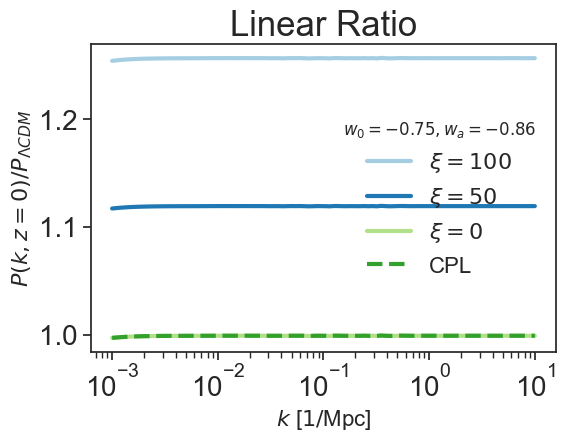

In [9]:
# Create the figure
plt.figure(figsize=(6, 4))
plt.semilogx(ks, ps_ds_xi100[0]/ps_lcdm[0], label="$\\xi=100$")
plt.semilogx(ks, ps_ds_xi50[0]/ps_lcdm[0], label="$\\xi=50$")
plt.semilogx(ks, ps_ds_xi0[0]/ps_lcdm[0], label="$\\xi=0$")
plt.semilogx(ks, ps_cpl[0]/ps_lcdm[0], label="CPL", linestyle='--')
plt.xlabel('$k$ [$1/$Mpc]', fontsize = 16)
plt.ylabel('$P(k, z=0)/P_{\Lambda CDM}$', fontsize = 16)
plt.legend(fontsize = 16, title=f'$w_0={w0}, w_a={wa}$', frameon=False)
plt.title("Linear Ratio")

In [10]:
boost_ds_xi100 = MGemuNonlinearBoost(background_cpl, linear_perturbations_ds_xi100, zs, gravity_model='ide', mgpars={'xi': 100.})
boost_ds_xi50 = MGemuNonlinearBoost(background_cpl, linear_perturbations_ds_xi50, zs, gravity_model='ide', mgpars={'xi': 50.})
boost_ds_xi0 = MGemuNonlinearBoost(background_cpl, linear_perturbations_ds_xi0, zs, gravity_model='ide', mgpars={'xi': 0.})

Loading nonlinear emulator...
Nonlinear emulator loaded in memory.
Loading nonlinear emulator...
Nonlinear emulator loaded in memory.
Loading nonlinear emulator...
Nonlinear emulator loaded in memory.


Text(0.5, 1.0, 'Boosts')

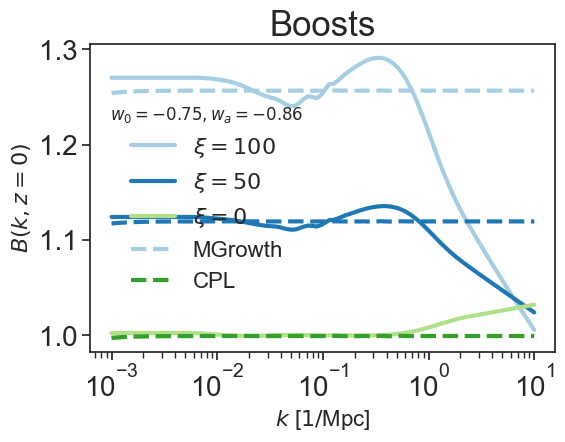

In [11]:
# Create the figure
plt.figure(figsize=(6, 4))
plt.semilogx(ks, boost_ds_xi100.mg_spectrum_boost(0., ks)[0], label="$\\xi=100$", color='C0')
plt.semilogx(ks, boost_ds_xi50.mg_spectrum_boost(0., ks)[0], label="$\\xi=50$", color='C1')
plt.semilogx(ks, boost_ds_xi0.mg_spectrum_boost(0., ks)[0], label="$\\xi=0$", color='C2')

plt.semilogx(ks, ps_ds_xi100[0]/ps_lcdm[0], color='C0', linestyle='--', label='MGrowth')
plt.semilogx(ks, ps_ds_xi50[0]/ps_lcdm[0], color='C1', linestyle='--')
plt.semilogx(ks, ps_ds_xi0[0]/ps_lcdm[0], color='C2', linestyle='--')
plt.semilogx(ks, ps_cpl[0]/ps_lcdm[0], label="CPL", linestyle='--', color='C3')

plt.xlabel('$k$ [$1/$Mpc]', fontsize = 16)
plt.ylabel('$B(k, z=0)$', fontsize = 16)
plt.legend(fontsize = 16, title=f'$w_0={w0}, w_a={wa}$', frameon=False)

plt.title("Boosts")

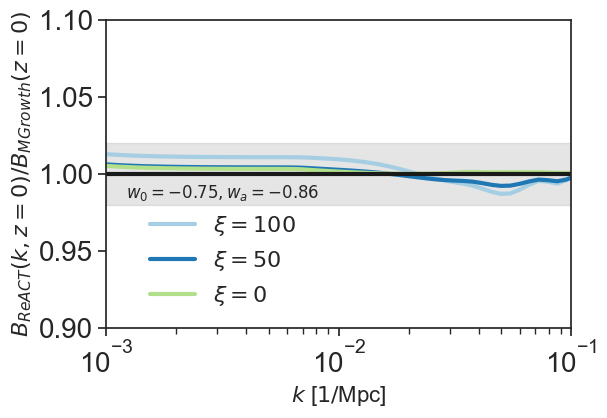

In [14]:
# Create the figure
plt.figure(figsize=(6, 4))
plt.semilogx(ks, boost_ds_xi100.mg_spectrum_boost(0., ks)[0]/(ps_ds_xi100[0]/ps_lcdm[0]), label="$\\xi=100$", color='C0')
plt.semilogx(ks, boost_ds_xi50.mg_spectrum_boost(0., ks)[0]/(ps_ds_xi50[0]/ps_lcdm[0]), label="$\\xi=50$", color='C1')
plt.semilogx(ks, boost_ds_xi0.mg_spectrum_boost(0., ks)[0]/(ps_ds_xi0[0]/ps_lcdm[0]), label="$\\xi=0$", color='C2')

plt.xlim(0.001, 0.1)
plt.ylim(0.9, 1.1)
plt.axhline(y=1, color='k')
plt.fill_between(ks, 1.02, 0.98, color='grey', alpha=0.2)
plt.xlabel('$k$ [$1/$Mpc]', fontsize = 16)
plt.ylabel('$B_{ReACT}(k, z=0)/B_{MGrowth}(z=0)$', fontsize = 16)
plt.legend(fontsize = 16, title=f'$w_0={w0}, w_a={wa}$', frameon=False)


In [12]:
nonlinear_perturbations_ds_xi100 = BoostedPerturbations(linear_perturbations_ds_xi100, nonlinear_perturbations_lcdm_nonu, boost_ds_xi100.MGboost_interp)
nonlinear_perturbations_ds_xi50 = BoostedPerturbations(linear_perturbations_ds_xi50, nonlinear_perturbations_lcdm_nonu, boost_ds_xi50.MGboost_interp)
nonlinear_perturbations_ds_xi0 = BoostedPerturbations(linear_perturbations_ds_xi0, nonlinear_perturbations_lcdm_nonu, boost_ds_xi0.MGboost_interp)

In [13]:
ps_lcdm_nl = nonlinear_perturbations_lcdm.matter_power_spectrum(0, ks)
ps_cpl_nl = nonlinear_perturbations_cpl.matter_power_spectrum(0, ks)
ps_ds_xi100_nl = nonlinear_perturbations_ds_xi100.matter_power_spectrum(0, ks)
ps_ds_xi50_nl = nonlinear_perturbations_ds_xi50.matter_power_spectrum(0, ks)
ps_ds_xi0_nl = nonlinear_perturbations_ds_xi0.matter_power_spectrum(0, ks)

<>:8: SyntaxWarning: invalid escape sequence '\L'
<>:8: SyntaxWarning: invalid escape sequence '\L'
/var/folders/h4/nm88s1d55cb19yw7pxm0tzs40000gn/T/ipykernel_11888/908859092.py:8: SyntaxWarning: invalid escape sequence '\L'
  plt.ylabel('$P(k, z=0)/P_{\Lambda CDM}$', fontsize = 16)


Text(0.5, 1.0, 'Nonlinear Ratio')

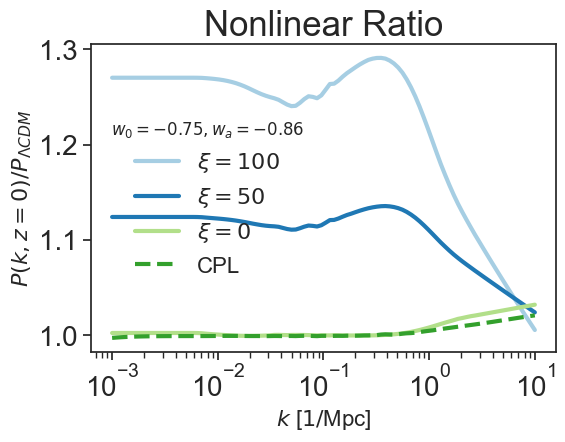

In [14]:
# Create the figure
plt.figure(figsize=(6, 4))
plt.semilogx(ks, ps_ds_xi100_nl/ps_lcdm_nl[0], label="$\\xi=100$")
plt.semilogx(ks, ps_ds_xi50_nl/ps_lcdm_nl[0], label="$\\xi=50$")
plt.semilogx(ks, ps_ds_xi0_nl/ps_lcdm_nl[0], label="$\\xi=0$")
plt.semilogx(ks, ps_cpl_nl[0]/ps_lcdm_nl[0], label="CPL", linestyle='--')
plt.xlabel('$k$ [$1/$Mpc]', fontsize = 16)
plt.ylabel('$P(k, z=0)/P_{\Lambda CDM}$', fontsize = 16)
plt.legend(fontsize = 16, title=f'$w_0={w0}, w_a={wa}$', frameon=False)
plt.title("Nonlinear Ratio")

In [15]:
data_path = "TR1_data/"
# Get n(z)
z_nz_pos, nz_pos = el.phz.redshift_distributions(data_path+'TR1_v1_Nz_GC_C2020_sel_pv.fits')
z_nz_she, nz_she = el.phz.redshift_distributions(data_path+'TR1_v1_Nz_WL_C2020_sel_pv.fits')


# Normalize and resample n(z) for both position and shear
myz = np.linspace(1e-4, 3.0, 100)
def normalize_and_resample(nz_dict, z_grid, z_target):
    nz_array = np.vstack([nz / integrate.trapezoid(nz, z_grid) for nz in nz_dict.values()])
    return np.array([np.interp(z_target, z_grid, nz) for nz in nz_array])

my_dndz_pos_norm = normalize_and_resample(nz_pos, z_nz_pos, myz)
my_dndz_she_norm = normalize_and_resample(nz_she, z_nz_she, myz)

In [16]:
full_cov=np.load(data_path+'covariance_Gauss_Euclid_DR1_brighter_cut_1589_TR1_2D.npz')['Gauss']

In [17]:
fiducial_nuisance = {
    # Intrinsic alignment
    'AIA': 0.16, 'EtaIA': 1.66, 'CIA': 0.0134,
    # Galaxy bias (poly coefficients)
    'b1_photo_poly0': 1.33291, 'b1_photo_poly1': -0.72414, 
    'b1_photo_poly2': 1.0183, 'b1_photo_poly3': -0.14913,
    # Magnification bias (per bin)
    'magnification_bias_1': 0.0, 'magnification_bias_2': 0.0,
    'magnification_bias_3': 0.0, 'magnification_bias_4': 0.0,
    'magnification_bias_5': 0.0, 'magnification_bias_6': 0.0,
    # Redshift errors (positions)
    'dz_pos_1': 0.0, 'dz_pos_2': 0.0, 'dz_pos_3': 0.0, 
    'dz_pos_4': 0.0, 'dz_pos_5': 0.0, 'dz_pos_6': 0.0,
    # Multiplicative shear bias
    'multiplicative_bias_1': 0.0, 'multiplicative_bias_2': 0.0,
    'multiplicative_bias_3': 0.0, 'multiplicative_bias_4': 0.0,
    'multiplicative_bias_5': 0.0, 'multiplicative_bias_6': 0.0,
    # Redshift errors (shear)
    'dz_shear_1': 0.0, 'dz_shear_2': 0.0, 'dz_shear_3': 0.0,
    'dz_shear_4': 0.0, 'dz_shear_5': 0.0, 'dz_shear_6': 0.0,
    'width_pos_1': 1.0, 'width_pos_2': 1.0,
    'width_pos_3': 1.0, 'width_pos_4': 1.0,
    'width_pos_5': 1.0, 'width_pos_6': 1.0,
    'width_shear_1': 1.0, 'width_shear_2': 1.0,
    'width_shear_3': 1.0, 'width_shear_4': 1.0,
    'width_shear_5': 1.0, 'width_shear_6': 1.0,
}

In [18]:
ell_theory = np.array([
    10.97557970,
    13.11709027,
    15.67644367,
    18.73516773,
    22.39069761,
    26.75947964,
    31.98068069,
    38.22062129,
    45.67807378,
    54.59059412,
    65.24208925,
    77.97186088,
    93.18541388,
    111.36737359,
    133.09692347,
    159.06625492,
    190.10261691,
    227.19466787,
    271.52396925,
    324.50262398,
    387.81825878,
    463.48778323,
    553.92163814,
    662.00057974,
    791.16744571,
    945.53682628,
    1130.02613377,
    1350.51224608,
    1614.01871364,
    1928.93949355,
    2305.30633773,
    2755.10835283
])
len(ell_theory)

32

In [19]:
def compute_cells(perturbations):
    # Tracer definitions (easy to swap dndz, bias model, etc.)
    tracer_pos = PositionsTracer(
        perturbations=perturbations,
        dndz=my_dndz_pos_norm,
        z=myz,
        galaxy_bias_model='poly',
        nuisance_params=fiducial_nuisance
    )
    
    tracer_she = ShearTracer(
        perturbations=perturbations,
        dndz=my_dndz_she_norm,
        z=myz,
        nuisance_params=fiducial_nuisance
    )
    # 🎯 Compute all the 2-point angular power spectra in one go!
    cls_sheshe = AngularTwoPoint(tracer_she, tracer_she).get_Cl(ell_theory, 0, perturbations.k)
    cls_posshe = AngularTwoPoint(tracer_pos, tracer_she).get_Cl(ell_theory, 0, perturbations.k)
    cls_pospos = AngularTwoPoint(tracer_pos, tracer_pos).get_Cl(ell_theory, 0, perturbations.k)
    return cls_sheshe, cls_posshe, cls_pospos

In [20]:
labels = ['lcdm', 'cpl', 'ds_xi0', 'ds_xi50', 'ds_xi100']
cells_wl = {}
cells_ggl = {}
cells_gc = {}
labels_names = ['ΛCDM', 'CPL: $w_0=-0.75, w_a=-0.86$', '$\\xi=0$', '$\\xi=50$', '$\\xi=100$']

In [21]:
for label in labels:
    perturbations = eval(f'nonlinear_perturbations_{label}')
    cells_wl[label], cells_ggl[label], cells_gc[label] = compute_cells(perturbations)

In [22]:
# Extract weak lensing covariance submatrix
# Shape: (n_tomographic_pairs * n_ell_bins, n_tomographic_pairs * n_ell_bins)
# For 6 bins: (21+21)*32 = 1344 elements (EE + BB correlations)
cov_WL = full_cov[:21*32, :21*32]
print('WL cov: ', cov_WL.shape)

cov_GC = full_cov[-21*32:, -21*32:]
print('GC cov: ', cov_GC.shape)

cov_GGL = full_cov[21*32:-21*32, 21*32:-21*32]
print('GGL cov: ', cov_GGL.shape)

print('full cov: ', full_cov.shape)

WL cov:  (672, 672)
GC cov:  (672, 672)
GGL cov:  (1152, 1152)
full cov:  (2496, 2496)


In [23]:
errors_wl = np.sqrt(np.diag(cov_WL))
pairs_wl = []
nbin = 6
for i in range(nbin):
    for j in range(i+1):
        pairs_wl.append((i, j))
errors_gc = np.sqrt(np.diag(cov_GC))
pairs_gc = []
for i in range(nbin):
    for j in range(i+1):
        pairs_gc.append((i, j))
errors_ggl = np.sqrt(np.diag(cov_GGL))
pairs_ggl = []
for i in range(nbin):
    for j in range(nbin):
        pairs_ggl.append((i, j))

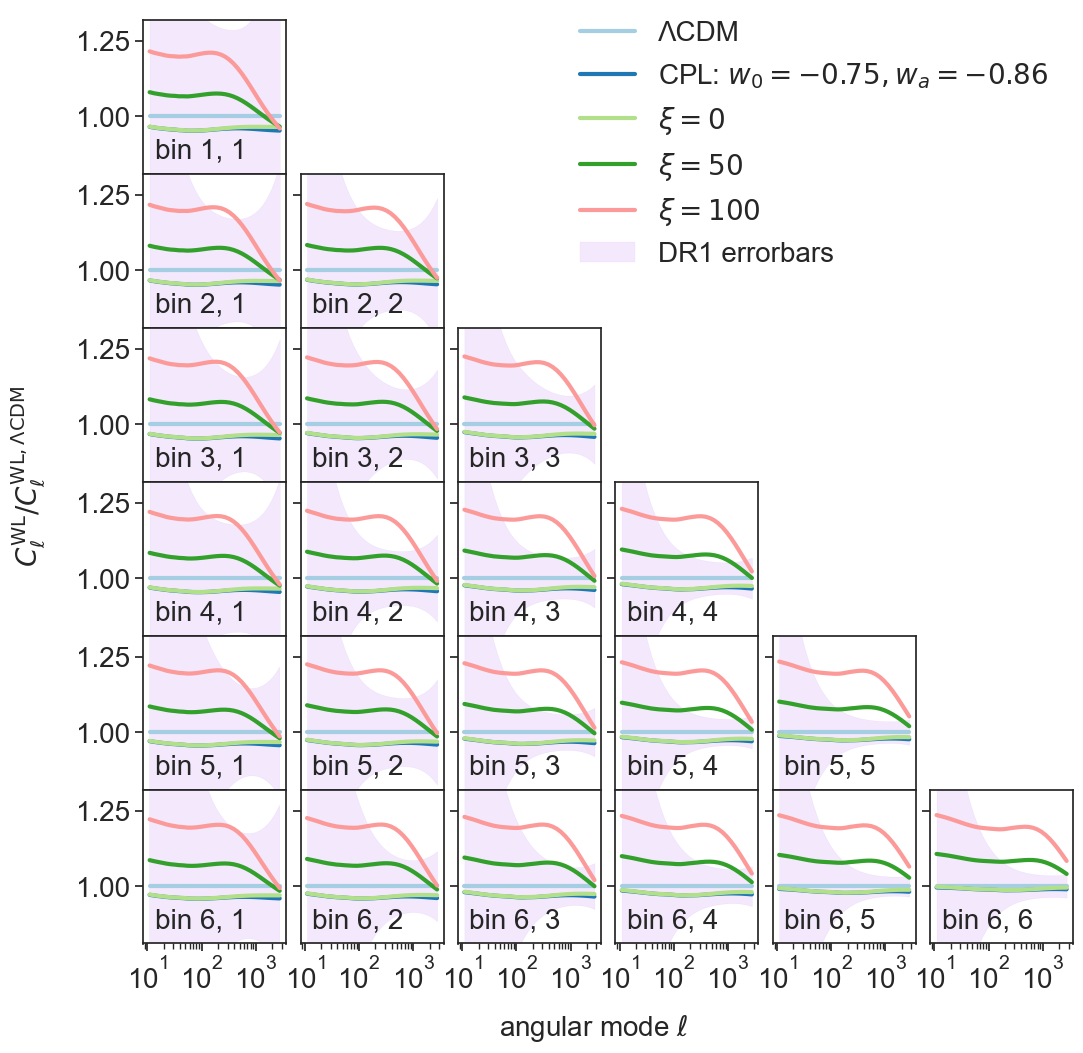

In [24]:
nbin = 6
nell = 32

fig, ax = plt.subplots(nbin, nbin, figsize=(12, 12), sharey='row', sharex=True, gridspec_kw={'wspace': 0.1, 'hspace': 0})
for i in range(nbin):
    for j in range(nbin):
        if i >= j:
            # find index of this pair
            p = pairs_wl.index((i, j))
            
            start = p * nell
            end = (p + 1) * nell
            err = errors_wl[start:end]/cells_wl['lcdm'][('SHE', 'SHE', j+1, i+1)][0, 0]
            for label in labels:
                y = cells_wl[label][('SHE', 'SHE', j+1, i+1)][0, 0]/cells_wl['lcdm'][('SHE', 'SHE', j+1, i+1)][0, 0]
                ax[i,j].semilogx(ell_theory,  y)
            
            # shaded region
            ax[i,j].fill_between(
                    ell_theory,
                    1. - err,
                    1. + err,
                    color='#d8b4f8',
                    alpha=0.3,
                    linewidth=0.3
                )

            ax[i,j].text(.4, .1, 'bin %s, %s'%(str(i+1),(j+1)), fontsize="medium", horizontalalignment='center', transform=ax[i,j].transAxes)
            #ax[i, j].axvspan(xmin=200, xmax=ell_theory[-1], color='grey', alpha=0.1)
            #ax[i, j].axvspan(xmin=500, xmax=ell_theory[-1], color='grey', alpha=0.2)
            #ax[i, j].axvspan(xmin=1500, xmax=ell_theory[-1], color='grey', alpha=0.5)
            ax[i, j].set_ylim(0.81, 1.32)
        else:
            ax[i,j].axis('off')       
fig.text(0.03, 0.5, r'$C^{\rm WL}_{\ell}/C^{\rm WL, ΛCDM}_{\ell}$', ha='center', va='center', rotation='vertical', fontsize=20)
fig.text(0.5, 0.04, r'angular mode $\ell$', ha='center', va='center', fontsize=20)   
fig.legend(labels_names+['DR1 errorbars'],  loc='upper right', ncol=1, bbox_to_anchor=(0.9, 0.9), bbox_transform=fig.transFigure, fontsize=20, frameon=False, title_fontsize=20)
#plt.savefig('figures/nulltest_ds_shear.png', dpi=300, bbox_inches='tight')

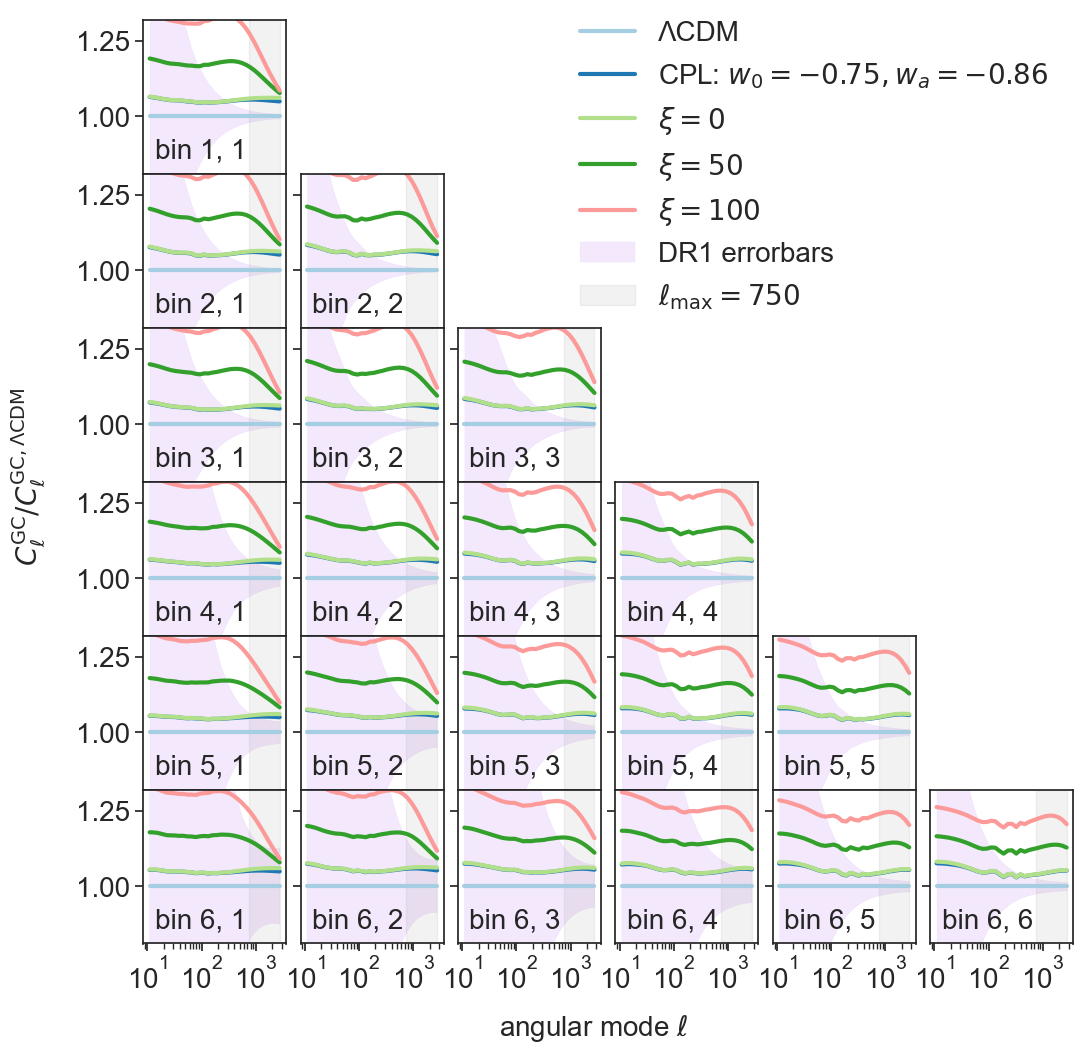

In [25]:
fig, ax = plt.subplots(nbin, nbin, figsize=(12, 12), sharey='row', sharex=True, gridspec_kw={'wspace': 0.1, 'hspace': 0})
for i in range(nbin):
    for j in range(nbin):
        if i >= j:
            # find index of this pair
            p = pairs_gc.index((i, j))
            
            start = p * nell
            end = (p + 1) * nell
            err = errors_gc[start:end]/cells_gc['lcdm'][('POS', 'POS', j+1, i+1)][:]
            for label in labels:
                y = cells_gc[label][('POS', 'POS', j+1, i+1)][:]/cells_gc['lcdm'][('POS', 'POS', j+1, i+1)][:]
                ax[i,j].semilogx(ell_theory,  y)
            
            # shaded region
            ax[i,j].fill_between(
                    ell_theory,
                    1. - err,
                    1. + err,
                    color='#d8b4f8',
                    alpha=0.3,
                    linewidth=0.3
                )

            ax[i,j].text(.4, .1, 'bin %s, %s'%(str(i+1),(j+1)), fontsize="medium", horizontalalignment='center', transform=ax[i,j].transAxes)
            ax[i, j].axvspan(xmin=750, xmax=ell_theory[-1], color='grey', alpha=0.1)
            #ax[i, j].axvspan(xmin=500, xmax=ell_theory[-1], color='grey', alpha=0.2)
            #ax[i, j].axvspan(xmin=1500, xmax=ell_theory[-1], color='grey', alpha=0.5)
            ax[i, j].set_ylim(0.81, 1.32)
        else:
            ax[i,j].axis('off')       
fig.text(0.03, 0.5, r'$C^{\rm GC}_{\ell}/C^{\rm GC, ΛCDM}_{\ell}$', ha='center', va='center', rotation='vertical', fontsize=20)
fig.text(0.5, 0.04, r'angular mode $\ell$', ha='center', va='center', fontsize=20)   
fig.legend(labels_names+['DR1 errorbars', '$\\ell_{\\rm max}=750$'],  loc='upper right', ncol=1, bbox_to_anchor=(0.9, 0.9), bbox_transform=fig.transFigure, fontsize=20, frameon=False, title_fontsize=20)
#plt.savefig('figures/nulltest_ds_gclustering.png', dpi=300, bbox_inches='tight')

Text(0.5, 0.04, 'angular mode $\\ell$')

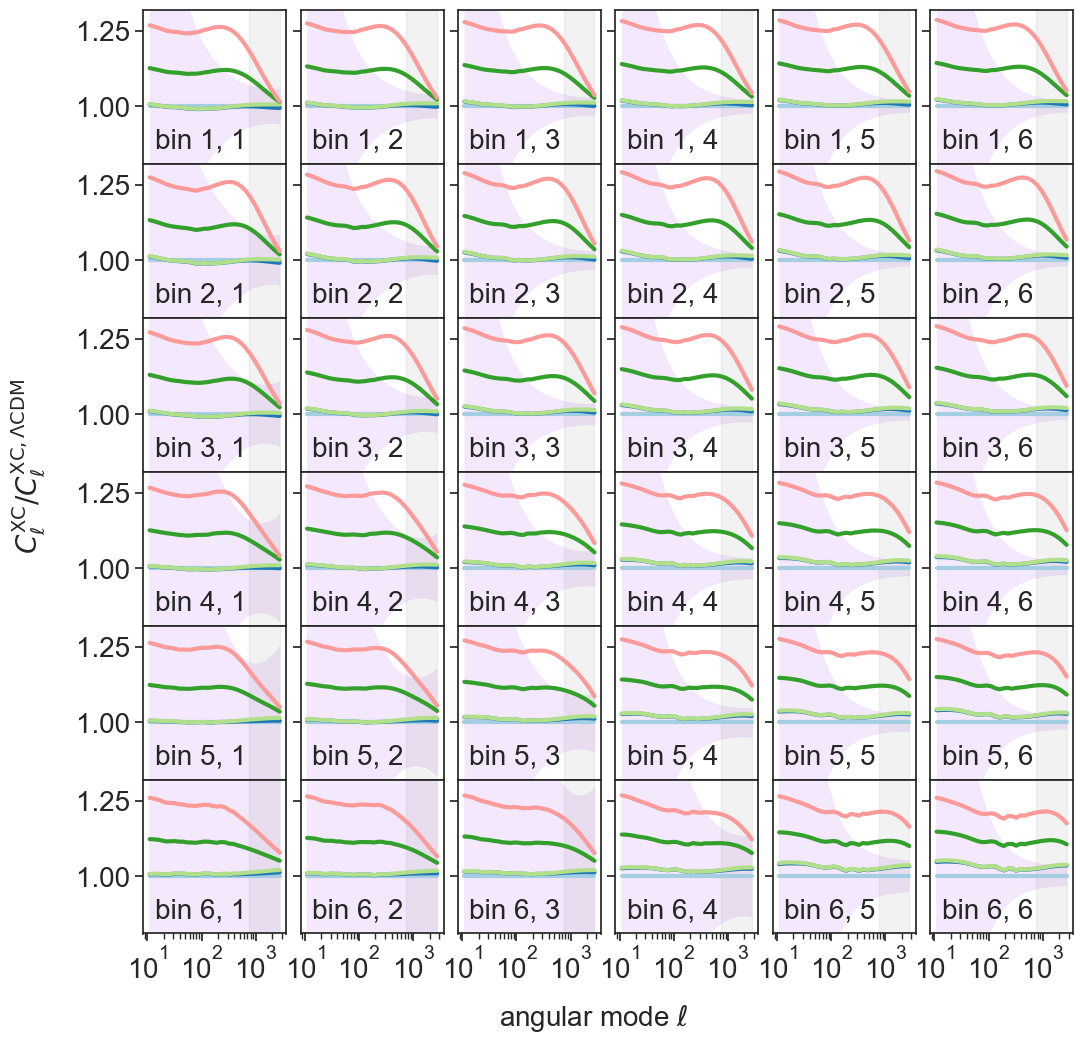

In [26]:
fig, ax = plt.subplots(nbin, nbin, figsize=(12, 12), sharey='row', sharex=True, gridspec_kw={'wspace': 0.1, 'hspace': 0})
for i in range(nbin):
    for j in range(nbin):
            # find index of this pair
            p = pairs_ggl.index((i, j))
            
            start = p * nell
            end = (p + 1) * nell
            err = errors_ggl[start:end]/cells_ggl['lcdm'][('POS', 'SHE', i+1, j+1)][0]
            for label in labels:
                y = cells_ggl[label][('POS', 'SHE', i+1, j+1)][0]/cells_ggl['lcdm'][('POS', 'SHE', i+1, j+1)][0]
                ax[i,j].semilogx(ell_theory,  y)
            
            # shaded region
            ax[i,j].fill_between(
                    ell_theory,
                    1. - err,
                    1. + err,
                    color='#d8b4f8',
                    alpha=0.3,
                    linewidth=0.3
                )

            ax[i,j].text(.4, .1, 'bin %s, %s'%(str(i+1),(j+1)), fontsize="medium", horizontalalignment='center', transform=ax[i,j].transAxes)
            ax[i, j].axvspan(xmin=750, xmax=ell_theory[-1], color='grey', alpha=0.1)
            #ax[i, j].axvspan(xmin=500, xmax=ell_theory[-1], color='grey', alpha=0.2)
            #ax[i, j].axvspan(xmin=1500, xmax=ell_theory[-1], color='grey', alpha=0.5)
            ax[i, j].set_ylim(0.81, 1.32)      
fig.text(0.03, 0.5, r'$C^{\rm XC}_{\ell}/C^{\rm XC, ΛCDM}_{\ell}$', ha='center', va='center', rotation='vertical', fontsize=20)
fig.text(0.5, 0.04, r'angular mode $\ell$', ha='center', va='center', fontsize=20)   
#fig.legend(labels_names+['DR1 errorbars', '$\\ell_{\\rm max}=750$'],  loc='upper right', ncol=1, bbox_to_anchor=(0.9, 0.9), bbox_transform=fig.transFigure, fontsize=20, frameon=False, title_fontsize=20)
#plt.savefig('figures/nulltest_ds_cross.png', dpi=300, bbox_inches='tight')

In [27]:
# Import cloelike for likelihoods
from cloelike.EuclidLikelihood_photo_Cls import EuclidLikelihood_3x2pt
fiducial_cosmology = {
    'H0': 67,                # Hubble constant
    'Omega_cdm0': 0.27,        # Cold dark matter density
    'Omega_b0': 0.049,         # Baryon density
    'Omega_k0': 0.0,           # Curvature
    'mnu': 0.00001,                # Neutrino mass
    'w0': -1.,                # Dark energy equation of state (present)
    'wa': 0.,                 # Dark energy equation of state (evolution)
    'ns': 0.96,                # Scalar spectral index
    'As': 2.1e-9, # Scalar amplitude
    'gamma_MG': 0.545,         # Modified gravity parameter
    'log10TAGN': None,          # AGN feedback parameter
    'N_mnu': 1,                  # Number of massive neutrino species
    'N_eff': 3.046             # Effective number of relativistic species
}


In [28]:
# 🚀 Combine all spectra into a single dictionary for easy access!
uncoupled_cls = {**cells_wl['lcdm'], **cells_ggl['lcdm'], **cells_gc['lcdm']}

def build_data(cls, mapa_key, cov, zs, nzs, include_pos=False, include_she=False):
    data = {
        'cells': cls,
        'ells': cls[mapa_key].ell,
        'z_arr': zs,
        'cov': cov,
        'mixmat': {},
    }
    if include_pos:
        data['dndz_pos'] = nzs[0]
    if include_she:
        data['dndz_she'] = nzs[1]
    return data

def build_settings(cls):
    scale_cuts = {}
    for key in cls:
        if key[:2] == ('POS', 'POS'):
            scale_cuts[key] = [60, 750] #[10, 750]

        elif key[:2] == ('POS', 'SHE'):
            scale_cuts[key] = [60, 750] #[10, 750]

        elif key[:2] == ('SHE', 'SHE'):
            scale_cuts[key] = [60, 1500] #[10, 1500]
    return {
        'n_ell_bins': 32,
        'scale_cuts': scale_cuts}

data_3x2pt  = build_data(uncoupled_cls, ('SHE', 'SHE', 1, 1), 
                             full_cov, 
                             myz, [my_dndz_pos_norm, my_dndz_she_norm],
                             include_pos=True, include_she=True)
settings_3x2pt  = build_settings(uncoupled_cls)

like_instance = EuclidLikelihood_3x2pt(
        data=data_3x2pt,
        settings=settings_3x2pt,
        Background=CAMBBackground,
        LinPerturbations=HMemuLinearPerturbations,
        NonLinPerturbations=HMemuNonLinearPerturbations,
        mode="uncoupled"
    )

loglike = like_instance.loglike(fiducial_cosmology | fiducial_nuisance)
print("✨ Log-likelihood at fiducial (3x2pt): ", loglike)
print("Fiducial sigma8_0 = ", like_instance.derived['sigma8_0'])

cpl_cosmology = fiducial_cosmology.copy()
cpl_cosmology['w0'] = -0.75
cpl_cosmology['wa'] = -0.86
loglike_cpl = like_instance.loglike(cpl_cosmology | fiducial_nuisance)
print("✨ Log-likelihood at CPL (3x2pt): ", loglike_cpl)
print("CPL sigma8_0 = ", like_instance.derived['sigma8_0'])

✨ Log-likelihood at fiducial (3x2pt):  0.0
Fiducial sigma8_0 =  0.8280182235114465
✨ Log-likelihood at CPL (3x2pt):  -67.49234050736946
CPL sigma8_0 =  0.8276801594517714


In [29]:
pars_fid = [-1., 0.]
cosmo_pars_labels = ['w_0', 'w_a']
cosmo_pars = ['w0', 'wa']
vary_pars_dic = {'w0':np.linspace(-3, -0.3, 64), 'wa':np.linspace(-2, 0.74, 64)  }
loglike_w0 = []
loglike_wa = []
for w0_i in vary_pars_dic['w0']:
    cpl_cosmology = fiducial_cosmology.copy()
    cpl_cosmology['w0'] = w0_i
    cpl_cosmology['wa'] = 0
    loglike_cpl = like_instance.loglike(cpl_cosmology | fiducial_nuisance)
    loglike_w0.append(loglike_cpl)

for wa_i in vary_pars_dic['wa']:
    cpl_cosmology = fiducial_cosmology.copy()
    cpl_cosmology['w0'] = -1.
    cpl_cosmology['wa'] = wa_i
    loglike_cpl = like_instance.loglike(cpl_cosmology | fiducial_nuisance)
    loglike_wa.append(loglike_cpl)

loglike = {'w0': loglike_w0, 'wa': loglike_wa}

In [30]:
like_instance_ds = EuclidLikelihood_3x2pt_DS(
        data=data_3x2pt,
        settings=settings_3x2pt,
        Background=CAMBBackground,
        LinPerturbations=MGrowthLinearPerturbations,
        NonLinPerturbations=BoostedPerturbations,
        mode="uncoupled"
    )

In [31]:
ds_cosmology = fiducial_cosmology.copy()
ds_cosmology['w0'] = -0.75
ds_cosmology['wa'] = -0.86
ds_cosmology['xi'] = 100.
loglike_ds = like_instance_ds.loglike(ds_cosmology | fiducial_nuisance)
print("✨ Log-likelihood at DS (3x2pt): ", loglike_cpl)
print("DS sigma8_0 = ", like_instance.derived['sigma8_0'])

Loading nonlinear emulator...
Nonlinear emulator loaded in memory.
Loading nonlinear emulator...
Nonlinear emulator loaded in memory.
Loading nonlinear emulator...
Nonlinear emulator loaded in memory.
✨ Log-likelihood at DS (3x2pt):  -1221.998266983425
DS sigma8_0 =  0.7323015767741932


In [33]:
xi_arr = np.linspace(0., 150., 64)
loglike_xi = []
for xi_i in xi_arr:
    ds_cosmology = fiducial_cosmology.copy()
    ds_cosmology['w0'] = -0.75
    ds_cosmology['wa'] = -0.86
    ds_cosmology['xi'] = xi_i
    loglike_ds = like_instance_ds.loglike(ds_cosmology | fiducial_nuisance)
    loglike_xi.append(loglike_ds)


Loading nonlinear emulator...
Nonlinear emulator loaded in memory.
Loading nonlinear emulator...
Nonlinear emulator loaded in memory.
Loading nonlinear emulator...
Nonlinear emulator loaded in memory.
Loading nonlinear emulator...
Nonlinear emulator loaded in memory.
Loading nonlinear emulator...
Nonlinear emulator loaded in memory.
Loading nonlinear emulator...
Nonlinear emulator loaded in memory.
Loading nonlinear emulator...
Nonlinear emulator loaded in memory.
Loading nonlinear emulator...
Nonlinear emulator loaded in memory.
Loading nonlinear emulator...
Nonlinear emulator loaded in memory.
Loading nonlinear emulator...
Nonlinear emulator loaded in memory.
Loading nonlinear emulator...
Nonlinear emulator loaded in memory.
Loading nonlinear emulator...
Nonlinear emulator loaded in memory.
Loading nonlinear emulator...
Nonlinear emulator loaded in memory.
Loading nonlinear emulator...
Nonlinear emulator loaded in memory.
Loading nonlinear emulator...
Nonlinear emulator loaded in mem

/var/folders/h4/nm88s1d55cb19yw7pxm0tzs40000gn/T/ipykernel_11888/1543793470.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend(title='$w_a=0$')
/var/folders/h4/nm88s1d55cb19yw7pxm0tzs40000gn/T/ipykernel_11888/1543793470.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend(title='$w_0=-1.$')
/var/folders/h4/nm88s1d55cb19yw7pxm0tzs40000gn/T/ipykernel_11888/1543793470.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[2].legend(title='$w_0=-0.75, w_a=-0.86$')


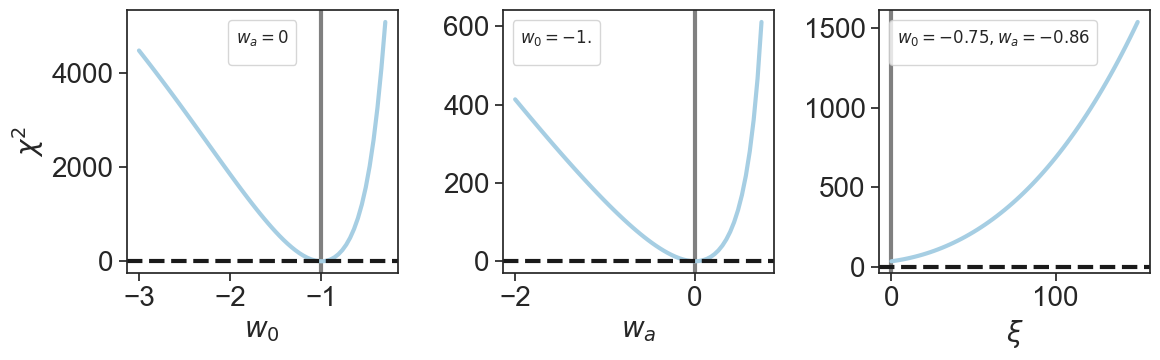

In [34]:
fig, ax = plt.subplots(figsize=(12, 4), nrows=1, ncols=3,facecolor='w')
for j in range(2):
    ax[j].axvline(pars_fid[j], color='grey')
    ax[j].plot(vary_pars_dic[cosmo_pars[j]], -0.5*np.array(loglike[cosmo_pars[j]]))
    ax[j].set_xlabel('$'+cosmo_pars_labels[j]+'$') 
    ax[j].axhline(0., color='k', linestyle='--')
ax[0].legend(title='$w_a=0$')
ax[1].legend(title='$w_0=-1.$')

ax[2].axvline(0., color='grey')
ax[2].plot(xi_arr, -0.5*np.array(loglike_xi))
ax[2].set_xlabel('$\\xi$') 
ax[2].axhline(0., color='k', linestyle='--')
ax[2].legend(title='$w_0=-0.75, w_a=-0.86$')
ax[0].set_ylabel('$\\chi^2$')        
plt.tight_layout()
#plt.savefig('figures/nulltest_ds_chi2.png', dpi=300, bbox_inches='tight')